In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import matplotlib.pyplot as plt
import seaborn as sns
csv_filename = 'nsi_MA.csv'

/Users/samuelsiu/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
'''
if not os.path.exists(csv_filename):
    df_raw = gpd.read_file('nsi_2022_25.gpkg')
    df_raw = df_raw.dropna(subset=['firmzone'])
    
    # these lines were I made for testing
    #sample_size = min(10000, len(df_raw))
    #df_raw = df_raw.sample(n=sample_size, random_state=33)
    
    if 'geometry' in df_raw.columns:
        df_raw = df_raw.drop(columns=['geometry'])
    df_raw.to_csv(csv_filename, index=False)
    print(f"saved to {csv_filename}")
'''

'\nif not os.path.exists(csv_filename):\n    df_raw = gpd.read_file(\'nsi_2022_25.gpkg\')\n    df_raw = df_raw.dropna(subset=[\'firmzone\'])\n    \n    # these lines were I made for testing\n    #sample_size = min(10000, len(df_raw))\n    #df_raw = df_raw.sample(n=sample_size, random_state=33)\n    \n    if \'geometry\' in df_raw.columns:\n        df_raw = df_raw.drop(columns=[\'geometry\'])\n    df_raw.to_csv(csv_filename, index=False)\n    print(f"saved to {csv_filename}")\n'

In [3]:
df = pd.read_csv(csv_filename)

high_risk_zones = ['VE', 'AE', 'A', 'AO', 'AH']
df['target_label'] = df['firmzone'].isin(high_risk_zones).astype(int)

num_cols = ['ground_elv', 'found_ht', 'val_struct', 'med_yr_blt', 'sqft', 'num_story']
cat_cols = ['bldgtype', 'found_type']

# one hot
Phi = pd.get_dummies(df[num_cols + cat_cols], drop_first=True)
X = Phi.values.astype(float)
y = df['target_label'].values.reshape(-1, 1)

np.random.seed(33)
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y = y[indices]

# split train and test sets
split_idx = int(0.8 * len(X))
X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
Y_train, Y_test = y[:split_idx], y[split_idx:]

# normalize
X_mean = np.mean(X_train_raw, axis=0)
X_std = np.std(X_train_raw, axis=0)

X_train = (X_train_raw - X_mean) / (X_std + 1e-8)
X_test = (X_test_raw - X_mean) / (X_std + 1e-8)

In [4]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

n = X_train.shape[0]
d = X_train.shape[1]
hidden_nodes = 16
out_nodes = 1
eta = 0.05
epochs = 2000 

np.random.seed(33)
W1 = np.random.randn(d, hidden_nodes) * np.sqrt(2.0 / d)
b1 = np.zeros((1, hidden_nodes))
W2 = np.random.randn(hidden_nodes, out_nodes) * np.sqrt(1.0 / hidden_nodes)
b2 = np.zeros((1, out_nodes))

def f(x):
    h = np.maximum(0, x.dot(W1) + b1)
    return sigmoid(h.dot(W2) + b2)

def compute_bce_loss(Y_true, Y_pred):
    epsilon = 1e-8
    Y_pred = np.clip(Y_pred, epsilon, 1 - epsilon)
    return -np.mean(Y_true * np.log(Y_pred) + (1 - Y_true) * np.log(1 - Y_pred))

In [5]:
errors = []

for epoch in range(epochs):
    h = np.maximum(0, X_train.dot(W1) + b1) 
    y_pred = sigmoid(h.dot(W2) + b2)
    dy = y_pred - Y_train 
    dW2 = h.T.dot(dy) / n
    db2 = np.sum(dy, axis=0, keepdims=True) / n
    mat1 = np.heaviside(h, 0) 
    dh = dy.dot(W2.T)
    
    dW1 = X_train.T.dot(dh * mat1) / n
    db1 = np.sum(dh * mat1, axis=0, keepdims=True) / n
    
    W2 = W2 - eta * dW2
    b2 = b2 - eta * db2
    W1 = W1 - eta * dW1
    b1 = b1 - eta * db1

    if epoch % 10 == 0:
        e = compute_bce_loss(Y_train, y_pred)
        errors.append(e)
        if epoch % 200 == 0:
            print(f"Epoch {epoch:<4} | Loss: {e:.4f}")


Epoch 0    | Loss: 0.9281
Epoch 200  | Loss: 0.2494
Epoch 400  | Loss: 0.1822
Epoch 600  | Loss: 0.1672
Epoch 800  | Loss: 0.1615
Epoch 1000 | Loss: 0.1585
Epoch 1200 | Loss: 0.1566
Epoch 1400 | Loss: 0.1552
Epoch 1600 | Loss: 0.1541
Epoch 1800 | Loss: 0.1533


In [6]:
A2_test = f(X_test)
predictions = (A2_test > 0.5).astype(int)

TP = np.sum((predictions == 1) & (Y_test == 1))
TN = np.sum((predictions == 0) & (Y_test == 0))
FP = np.sum((predictions == 1) & (Y_test == 0))
FN = np.sum((predictions == 0) & (Y_test == 1))

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"accuracy:  {accuracy * 100:.2f}%")
print(f"precision: {precision:.4f}")
print(f"recall:    {recall:.4f}")
print(f"f1-Score:  {f1_score:.4f}")

accuracy:  93.97%
precision: 0.9243
recall:    0.9440
f1-Score:  0.9341


In [7]:
# np.savez('mlp_weights.npz', W1=W1, b1=b1, W2=W2, b2=b2)
# data = np.load('mlp_weights.npz')
# W1, b1, W2, b2 = data['W1'], data['b1'], data['W2'], data['b2']

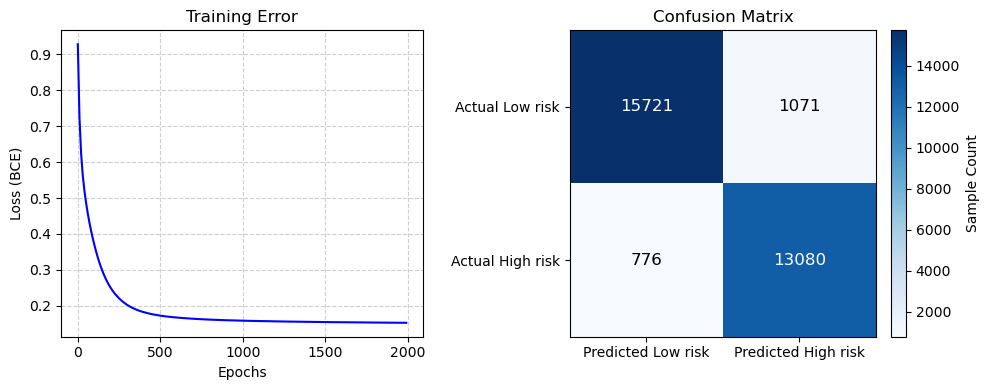

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(0, epochs, 10), errors, color='blue', linewidth=1.5)
plt.title('Training Error')
plt.xlabel('Epochs')
plt.ylabel('Loss (BCE)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.subplot(1, 2, 2)
conf_matrix = np.array([[TN, FP], 
                        [FN, TP]])


im = plt.imshow(conf_matrix, cmap='Blues')
cbar = plt.colorbar(im, fraction=0.046, pad=0.04) 
cbar.set_label('Sample Count')

threshold = np.max(conf_matrix) / 2.
for i in range(2):
    for j in range(2):
        color = "white" if conf_matrix[i, j] > threshold else "black"
        plt.text(j, i, str(conf_matrix[i, j]), 
                 ha='center', va='center', color=color, fontsize=12)
plt.xticks([0, 1], ['Predicted Low risk', 'Predicted High risk'])
plt.yticks([0, 1], ['Actual Low risk', 'Actual High risk'])
plt.title('Confusion Matrix')

plt.tight_layout()
# plt.savefig('mlp_results.png', dpi=300)
plt.show()